# Exploratory Data Analysis — Parfumo Fragrances

Builds on the cleaned dataset produced by `01_cleaning.ipynb` (`data/cleaned_data.parquet`). Run `01_cleaning.ipynb` first before continuing.  
Where `01_cleaning` focused on fixing structural issues, this notebook focuses on answering questions with the data.

## Table of Contents
1. [Setup](#1-setup)
2. [Helper Functions for Multi-Value Columns](#2-helper-functions-for-multi-value-columns)
3. [Analysis Ideas To Explore](#3-analysis-ideas-to-explore)
4. [Example Explorations](#4-example-explorations)

## 1. Setup

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Global plot style for the whole notebook
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['axes.titlepad'] = 6    # keep the title close to the plot area
plt.rcParams['axes.labelpad'] = 4    # keep axis titles close to their tick labels
plt.rcParams['figure.constrained_layout.use'] = True    # keep margin between labels/title and the figure's outer edge
plt.rcParams['figure.constrained_layout.h_pad'] = 0.3
plt.rcParams['figure.constrained_layout.w_pad'] = 0.3

# Font fallback chain so non-Latin brand/text (Japanese, Korean, Chinese) renders correctly
plt.rcParams['font.family'] = ['DejaVu Sans', 'Yu Gothic', 'Malgun Gothic', 'Microsoft YaHei']

df = pd.read_parquet("../data/cleaned_data.parquet")
df.shape

(59239, 16)

## 2. Helper Functions for Multi-Value Columns

`Main_Accords`, `Top_Notes`, `Middle_Notes`, `Base_Notes`, and `Perfumers` are comma-separated strings.  
`explode_multi_value` / `value_counts_multi` turn one of these columns into one-item-per-row for frequency counts.

`contains_value` builds a boolean mask so it can filter/count fragrances by any note, accord, or perfumer, with an `exact` flag to choose between a whole-item match (`"Lemon"`) and a substring match (`"lemon"` also catching `"Italian lemon"`).

In [138]:
def explode_multi_value(df, column, sep=","):
    """One row per individual item in a comma-separated column (whitespace stripped)."""
    return df[column].str.split(sep).explode().str.strip()


def value_counts_multi(df, column, sep=","):
    """Frequency count of individual values inside a comma-separated column."""
    return explode_multi_value(df, column, sep).value_counts()


def contains_value(df, columns, term, exact=True, case_sensitive=False):
    """
    Boolean mask over df: rows where any of `columns` contains `term`.

    exact=True  -> matches a whole comma-separated item ("Lemon" != "Italian lemon")
    exact=False -> substring match ("Lemon" also matches "Italian lemon zest")
    """
    if isinstance(columns, str):
        columns = [columns]

    term_cmp = term if case_sensitive else term.lower()
    mask = pd.Series(False, index=df.index)

    def row_match(cell_items):
        if not isinstance(cell_items, list):
            return False
        for item in cell_items:
            item = item.strip()
            item_cmp = item if case_sensitive else item.lower()
            if (exact and item_cmp == term_cmp) or (not exact and term_cmp in item_cmp):
                return True
        return False

    for col in columns:
        mask = mask | df[col].str.split(",").apply(row_match)

    return mask

## 3. Analysis Ideas To Explore

Grounded in what's actually in `cleaned_data.parquet` (`Rating_Value`, `Rating_Count`, `Release_Year`, `Concentration_Group`, `Brand`, `Perfumers`, `Main_Accords`, `Top/Middle/Base_Notes`, `completeness`):

**Ratings & popularity**
- Distribution of `Rating_Value` — is it normal, or skewed toward high ratings (median was 7.4 in cleaning)?
- Relationship between `Rating_Count` (popularity) and `Rating_Value` (quality) — do more-reviewed fragrances rate higher, lower, or is there no relationship?
- Top brands by average rating, filtered to a minimum `Rating_Count` (e.g. ≥20) to avoid a handful of 10/10 votes on obscure fragrances dominating the ranking.

**Temporal trends**
- Has average `Rating_Value` shifted across decades — are older or newer fragrances rated better?
- Release volume over time already shown in cleaning (heavy skew to 2000s–2020s) — worth checking if that's brand-driven (a few brands flooding recent decades) or industry-wide.

**Notes & accords**
- Which individual notes/accords correlate with higher ratings (`explode_multi_value` + `groupby` on `Rating_Value`, already prototyped below for `Top_Notes`).
- Does note *count* (top+middle+base combined) relate to rating — do simpler or more complex compositions rate better?
- Which accords cluster together most often (e.g. does "Oud" pair predominantly with "Woody"/"Amber", or does it show up in unexpected combinations)?

**Concentration type**
- Does `Concentration_Group` (Eau de Parfum vs Eau de Toilette vs Extrait/Parfum etc.) correlate with `Rating_Value`?
- Does concentration type shift by decade (e.g. has Extrait/Parfum become more common recently, reflecting the niche-fragrance trend)?

**Brands & perfumers**
- Most prolific perfumers, and whether their portfolio ratings are more consistent (lower std) than average — "signature style" vs one-off work.
- Brands with the widest spread in ratings (highest std) — inconsistent quality vs a reliably narrow band.

**Data quality cross-checks**
- Does `completeness` correlate with `Rating_Value` or `Rating_Count` — are well-documented fragrances also the popular/well-rated ones (survivorship bias in what gets fully catalogued)?

### Ratings & Popularity

#### Distribution of Rating Values

A quick view at the overall distribution of Rating Values. Are fragrance ratings distributed normally? 

Only fragrances that have a Rating Value are included, which are roughly half the fragrances in the catalog.  
For better readablity values were grouped into 0.5-point buckets. 

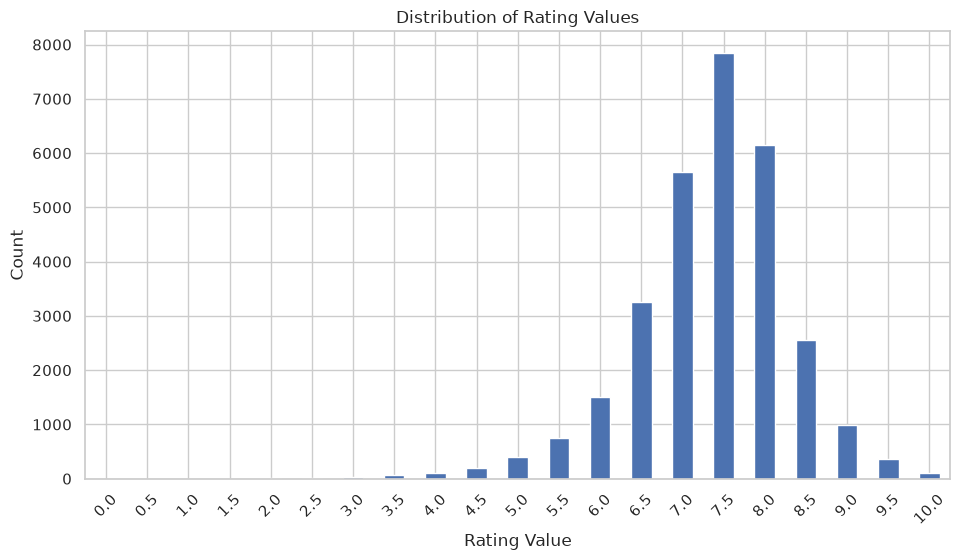

N = 30,001 fragrances with a Rating Value
Median Rating Value : 7.4


In [139]:
sub = df['Rating_Value'].dropna()

buckets = (sub * 2).round().div(2)
full_range = pd.Series(0, index=np.arange(0, 10.5, 0.5))    # make sure all buckets are represented, even if they have 0 counts
counts = buckets.value_counts().reindex(full_range.index, fill_value=0)

ax = counts.plot(kind='bar', figsize=(10, 6));

ax.tick_params(axis='x', rotation=45)
ax.set(xlabel='Rating Value', ylabel='Count', title='Distribution of Rating Values');
plt.show()  

print(f"N = {len(sub):,} fragrances with a Rating Value")
print(f"Median Rating Value : {sub.median()}")

**The data**

There's a clear single peak (mode) at 7.5, with 7.0 and 8.0 as strong neighbors: together these three buckets hold about 65% of all ~30k ratings.  
Mean = 7.35, median = 7.4 — very close together, with the mean sitting slightly below the median.  
Skewness = ‑0.82, indicating a left-skewed (negatively skewed) distribution.

**The meaning**

The distribution shows that users tend to rate fragrances quite positively: the bulk of ratings sits high, with a long, thin tail stretching down toward 0.  
Very few fragrances receive a perfect 10/10, which is expected in aggregated ratings, but scores below 5.0 are similarly rare.  
As with many rating platforms, this likely reflects a bias: a fragrance rated 5.0 is probably already considered mediocre or disappointing rather than "average." This seems to shift the perceived scale, so that ratings around 7 read as "good" and around 9 as "great."

#### Rating Count and Rating Value

Looking at the relationship between `Rating_Count` (popularity) and `Rating_Value` (quality) — do more-reviewed fragrances rate higher, lower, or is there no relationship?

Only fragrances with both a rating value and a rating count are considered. Again, roughly half the catalog (~29k of ~59k fragrances) has no ratings at all.   
Matplotlib silently skips these when plotting, which could hide the fact that so much of the catalog is being excluded — so they're dropped explicitly to keep the sample size and its limitations visible and intentional.

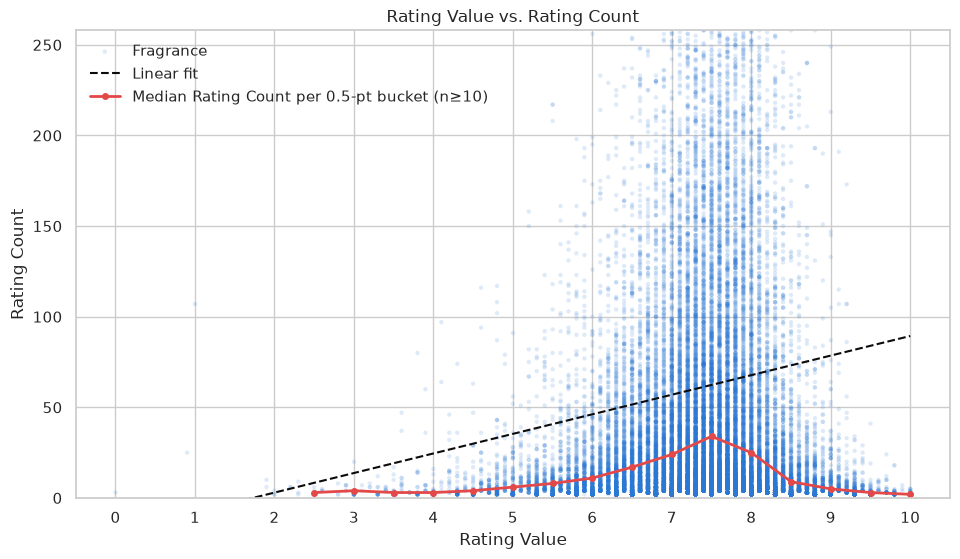

N = 30,001 fragrances with both a rating value and a rating count
Pearson r = 0.085
1496 fragrances with more than 258 ratings fall outside the y-axis above (up to 2,732 ratings) — excluded from view only, not from the fit
Rating buckets below 2.5 were dropped from the median trend line (fewer than 10 fragrances each — too small to give a stable median)


In [ ]:
sub = df.dropna(subset=["Rating_Value", "Rating_Count"])

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(sub["Rating_Value"], sub["Rating_Count"], s=10, alpha=0.15,
           color="#2a78d6", edgecolors="none", label="Fragrance")

# Linear fit via statsmodels OLS -- fit on the full data, not just the zoomed view below
fit_model = ols("Rating_Count ~ Rating_Value", data=sub).fit()
x_line = np.linspace(sub["Rating_Value"].min(), sub["Rating_Value"].max(), 100)
y_line = fit_model.predict(pd.DataFrame({"Rating_Value": x_line}))
ax.plot(x_line, y_line, color="#0b0b0b", linestyle="--",
         linewidth=1.5, label="Linear fit")

# Median Rating_Count per 0.5-point rating bucket. Buckets below Rating_Value 2.5 hold
# fewer than 10 fragrances each (some just 1-2), so their median is dominated by
# individual outliers rather than any real pattern -- drop those from the trend line
buckets = (sub["Rating_Value"] * 2).round().div(2)
bucket_size = buckets.value_counts()
MIN_BUCKET_N = 10
trend = sub["Rating_Count"].groupby(buckets).median()
trend = trend[bucket_size.reindex(trend.index) >= MIN_BUCKET_N]
ax.plot(trend.index, trend.values, color="#e34948", linewidth=2, marker="o",
         markersize=4, label=f"Median Rating Count per 0.5-pt bucket (n≥{MIN_BUCKET_N})")

# Zoom the y-axis to the 95th percentile so the linear axis stays readable;
# a handful of very heavily-rated fragrances fall outside the visible area (noted below)
y_cap = sub["Rating_Count"].quantile(0.95)
n_excluded = int((sub["Rating_Count"] > y_cap).sum())
ax.set_ylim(0, y_cap)
ax.set_xticks(np.arange(0, 11, 1))
ax.set(xlabel="Rating Value", ylabel="Rating Count",
       title="Rating Value vs. Rating Count")
ax.legend(frameon=False)
plt.show()

pearson_r = sub["Rating_Value"].corr(sub["Rating_Count"])
print(f"N = {len(sub):,} fragrances with both a rating value and a rating count")
print(f"Pearson r = {pearson_r:.3f}")
print(f"{n_excluded} fragrances with more than {y_cap:.0f} ratings fall outside the y-axis above "
      f"(up to {int(sub['Rating_Count'].max()):,} ratings) — excluded from view only, not from the fit")
print(f"Rating buckets below {trend.index.min()} were dropped from the median trend line "
      f"(fewer than {MIN_BUCKET_N} fragrances each — too small to give a stable median)")

**The data**

Pearson r ≈ 0.085 between `Rating_Value` and `Rating_Count` — r² ≈ 0.7%, meaning Rating_Value explains less than 1% of the variance in Rating_Count.  
The black linear-fit line does slope upward across this zoomed-in view, but don't be misled by that: the y-axis is capped at the 95th percentile (258 ratings) for readability, so the same slope that looks moderate here would look nearly flat against the true range (up to 2,732 ratings).  
~1,496 fragrances (5%) with more ratings than that aren't shown, though they're still included in the fit itself.

The red line (median `Rating_Count` per 0.5-point rating bucket, restricted to buckets with at least 10 fragrances) tells the more interesting story: starting around Rating_Value 2.5, it rises up to a peak around 7.0–7.5 (median ≈ 24–34 ratings), then falls back down at the high end — fragrances rated 9.5 or 10.0 have a median of only 2–3 ratings each. The relationship isn't linear, it's hump-shaped, which is exactly why a single correlation coefficient (or a straight fit line) isn't the full picture here.

Buckets below 2.5 are deliberately excluded from this line: the 1.0 bucket, for example, contains exactly two fragrances — both variants of the same "Boris Becker" release — whose rating counts (107 and 25) average to a median of 66. That's not a real trend, it's two data points; a bucket of size 1 or 2 can swing wildly and, left in, creates a second, misleading "hump" right at the low end of the chart.

**The meaning**

This pattern is consistent with  **regression to the mean**: with only a handful of raters, it's easy to land on an extreme average — a fragrance with 3 ratings only needs a few enthusiastic votes to average 9.5+. As the rater count grows, the average gets pulled toward the population's dominant sentiment (~7.5, the same peak seen in the rating distribution above), which is why the most-reviewed fragrances cluster in the 6.5–8.5 band rather than at the extremes. This also explains the >1,500-rating outliers sitting in the "middle field" rather than at the top: mass popularity pulls a score toward consensus, it doesn't push it toward perfection.

**Net takeaway:** `Rating_Count` is not a reliable proxy for quality — heavily-rated and lightly-rated fragrances span almost the same rating range, and if anything popularity acts as a *stabilizer* against extreme scores rather than a driver of higher ones. 

#### Top Brands by Average Rating

Which brands have the highest average `Rating_Value`?  
A simple ranking runs into an obvious problem: a brand with one fragrance rated 10/10 by two users would outrank Chanel. The usual fix is a minimum-ratings cutoff, but the check below suggests there isn't really a cutoff the data supports.

**Is there a natural cutoff?**   
A minimum-ratings threshold only makes sense if reliability actually stabilizes at some point — if fragrances with 20+ ratings are basically safe to average while anything below that isn't. To check, fragrances were bucketed by `Rating_Count` and then looked at how much `Rating_Value` still varies within each bucket.

In [141]:
bins = [2, 5, 10, 15, 20, 30, 50, 100, 200, 500, sub["Rating_Count"].max() + 1]
labels = ["2-4", "5-9", "10-14", "15-19", "20-29", "30-49", "50-99", "100-199", "200-499", "500+"]
count_bucket = pd.cut(sub["Rating_Count"], bins=bins, labels=labels, right=False)
sub.groupby(count_bucket, observed=True)["Rating_Value"].agg(n="size", std="std").round(2)

,n,std
Rating_Count,,
2-4,5933,1.32
5-9,4601,1.06
10-14,2808,0.94
15-19,1994,0.85
20-29,2659,0.80
30-49,3186,0.71
50-99,3841,0.63
100-199,2792,0.58
200-499,1740,0.49


**No knee.** The spread drops off smoothly, from about 1.3 at 2-4 ratings down to 0.45 at 500+, which is just standard-error shrinking as 1/√n. This pattern does not support an emerging cutoff-point. So drawing a cutoff point would be arbitrary and not supported by data.

Rather than pick a threshold, the ranking below uses a **Bayesian shrinkage estimator**, it's the same principle behind IMDB's weighted rating:

$$WR = \frac{v}{v+m} \cdot R + \frac{m}{v+m} \cdot C$$

- `R` — the brand's own rating-count-weighted average
- `v` — the brand's exposure (total ratings across its fragrances)
- `C` — the population mean across all rated fragrances
- `m` — the shrinkage constant: the same for every brand (272), equal to the **median** number of ratings `v` across all 1,288 rated brands .

 `m` is the point where a brand's own average and the population mean get equal (50/50) weight.  
Brands with little exposure (`v` << `m`) get pulled toward `C`; brands with a lot of exposure (`v` >> `m`) keep most of their own signal `R`.

163 brands still get no score — they have zero rated fragrances, so there's nothing to average.

`C` (7.50) is higher than the unweighted mean reported earlier (7.35) because it weights every rating equally, not every fragrance -  
 and popular fragrances skew slightly higher-rated (r ≈ 0.085).

This shrinkage example shows the Weighted Rating in action:

```
Chanel: n=117, total_count=20294, own weighted avg=7.98 -> WR=7.97
Asabi:  n=1,   total_count=2,     own weighted avg=9.00 -> WR=7.51
```

Chanel's 20k+ ratings barely move its score, while a brand with one 2-rating fragrance gets pulled almost all the way to `C`.

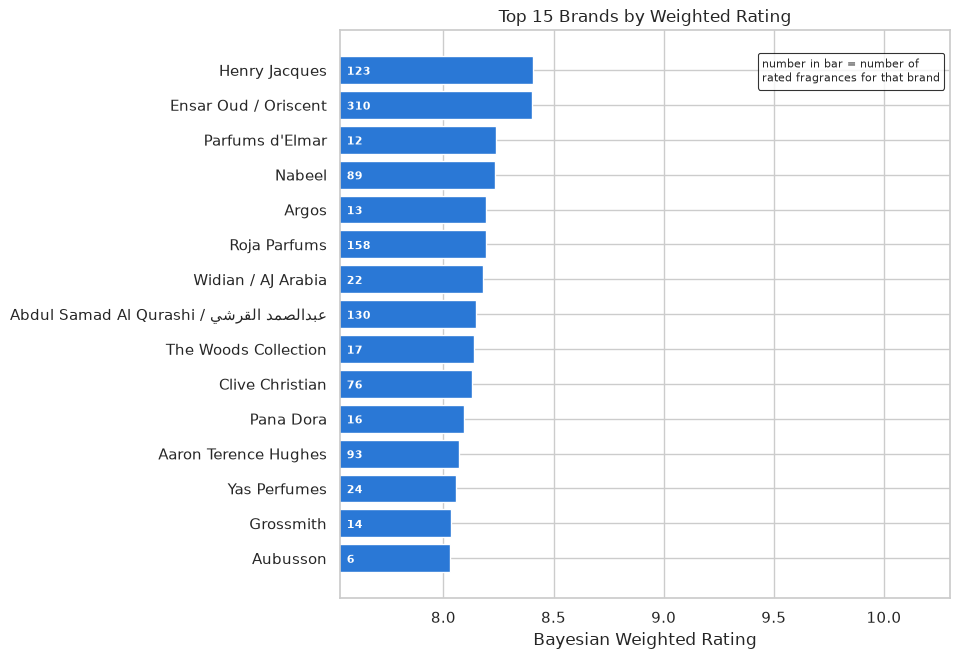

C (population mean, rating-count-weighted) = 7.50
m (shrinkage constant = median brand exposure) = 272 total ratings
1,288 of 1,451 brands get a WR score; 163 have zero rated fragrances and are absent


In [142]:
TOP_N = 15

brand_stats = sub.groupby("Brand").agg(n=("Rating_Value", "size"), total_count=("Rating_Count", "sum"))
brand_stats["weighted_avg"] = (
    (sub["Rating_Value"] * sub["Rating_Count"]).groupby(sub["Brand"]).sum() / brand_stats["total_count"]
)

# Population mean C, and shrinkage constant m = the median brand's total exposure, so a
# "typical" brand gets its own signal and the population mean weighted about 50/50, while a
# brand with far more exposure than that trusts its own average almost entirely.
C = (sub["Rating_Value"] * sub["Rating_Count"]).sum() / sub["Rating_Count"].sum()
m = brand_stats["total_count"].median()
v = brand_stats["total_count"]
brand_stats["WR"] = (v / (v + m)) * brand_stats["weighted_avg"] + (m / (v + m)) * C

top_wr = brand_stats["WR"].sort_values(ascending=False).head(TOP_N)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_wr.index[::-1], top_wr.values[::-1], color="#2a78d6")
ax.set_xlim(top_wr.min() - 0.5, 10.3)
ax.set(xlabel="Bayesian Weighted Rating", ylabel="",
       title=f"Top {TOP_N} Brands by Weighted Rating")

# Number of rated fragrances behind each brand's WR, left-aligned inside every bar 
label_x = ax.get_xlim()[0] + 0.03
for bar, brand in zip(bars, top_wr.index[::-1]):
    n = brand_stats.loc[brand, "n"]
    ax.text(label_x, bar.get_y() + bar.get_height() / 2 - 0.05, f"{n}",
            va="center", ha="left", fontsize=8, color="white", fontweight="bold")

legend_handle = Line2D([], [], color="none")
legend = ax.legend([legend_handle],
          ["number in bar = number of\nrated fragrances for that brand"],
          bbox_to_anchor=(1,0.97), frameon=True, handlelength=0, handletextpad=0, fontsize=8)
legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("black")
legend.get_frame().set_linewidth(0.8)

plt.show()

n_total_brands = df["Brand"].nunique()
n_unrated_brands = n_total_brands - len(brand_stats)
print(f"C (population mean, rating-count-weighted) = {C:.2f}")
print(f"m (shrinkage constant = median brand exposure) = {m:.0f} total ratings")
print(f"{len(brand_stats):,} of {n_total_brands:,} brands get a WR score; "
      f"{n_unrated_brands:,} have zero rated fragrances and are absent")

⚠️ **Known limitations:** Nr. 15 here (Aubusson) ranks on largely stale, discontinued-fragrance data, and The Woods Collection's low `n` is undercounted due to the same scraping cap — see [`03_limitations.ipynb`](03_limitations.ipynb) §1 and §2 for details.

**The data**

Following the designer/niche split from `01_cleaning.ipynb`, all 15 brands here classify as `Niche`: a first signal that niche brands are rated more generously than designer houses.

Within the field, four brands are Gulf-owned **oud specialists** — Nabeel, Widian/AJ Arabia, Abdul Samad Al Qurashi, and Yas Perfumes — joined by Ensar Oud/Oriscent, a US-based producer with oud focus. The remaining ten split between **Western heritage/ultra-luxury ateliers** (Henry Jacques, Parfums d'Elmar, Roja Parfums, Clive Christian, Grossmith) and **small indie, story-driven brands** (Argos, The Woods Collection, Pana Dora, Aaron Terence Hughes, Aubusson).

The number of rated fragrances behind each brand's score also splits cleanly in two: eight brands sit at 24 or fewer, the other seven at 76 or more, nothing in between. That split cuts across origin and style alike, so it isn't an Arabian-vs-Western divide.

**The meaning**

The complete absence of designer houses here likely traces back to the Rating Count vs. Rating Value finding: fragrances with high rating counts regress toward the population mean instead of reaching extremes. Designer fragrances tend to carry mass-market rating volumes, which caps how far their averages can stray from ~7.5. Niche fragrances, with far smaller counts, have room to land a genuinely high average. What's left at the top is a mix of low-volume traditions — Gulf oud specialists, Western ateliers, indie perfumers — none of them anywhere near designer-scale exposure.

That raises the follow-up question:  
Now that every brand is scored the same way,  where do the *big* designer houses (Chanel, Dior, YSL, ...) actually land relative to niche perfumers? 

**Remembering "designer" vs. "niche"**

- **Designer / fashion house** — a brand recognized primarily from clothing, accessories, or leather goods (the kind of name on a runway or a handbag), where fragrance is a licensed line extension rather than the core business. E.g. Chanel, Dior, Yves Saint Laurent, Gucci, Prada, Hermès, Versace.
- **Niche / independent perfumery** — a brand whose entire business is fragrance, sometimes plus candles or home scents, with no clothing or leather-goods line. This covers both contemporary independent houses (Xerjoff, Amouage, Le Labo) and heritage perfumers (Guerlain, Creed) that were never fashion houses.



**Descriptive data**

In [143]:
brand_cat_full = df.drop_duplicates("Brand").set_index("Brand")["Brand_Category"]
full_counts = brand_cat_full.value_counts()
print(f"Of all {len(brand_cat_full)} brands in the dataset: {full_counts.get('Designer', 0)} designer, "
      f"{full_counts.get('Niche', 0)} niche (default), {full_counts.get('Unclassified', 0)} explicitly excluded")

brand_level = brand_stats.copy()
brand_level["category"] = brand_cat_full.reindex(brand_level.index)

counts = brand_level["category"].value_counts()
means = brand_level.groupby("category")["WR"].mean()
print(f"Of the {len(brand_level)} brands with at least one rated fragrance: "
      f"{counts.get('Designer', 0)} designer, {counts.get('Niche', 0)} niche (default), "
      f"{counts.get('Unclassified', 0)} explicitly excluded")
print(f"Mean Bayesian Weighted Rating — Designer: {means['Designer']:.2f}, "
      f"Niche: {means['Niche']:.2f}, Unclassified: {means['Unclassified']:.2f}")


Of all 1451 brands in the dataset: 193 designer, 1152 niche (default), 106 explicitly excluded
Of the 1288 brands with at least one rated fragrance: 192 designer, 997 niche (default), 99 explicitly excluded
Mean Bayesian Weighted Rating — Designer: 7.37, Niche: 7.50, Unclassified: 7.33


**Niche houses outperform the rest, but is the difference significant?**

Looking at the means, niche houses (7.5) outperform both designer (7.37) and unclassified brands (7.33). The question is whether those gaps are statistically sound or just sampling noise.

A one-way ANOVA on `WR ~ category` tests whether the three group means (Designer/Niche/Unclassified) differ at all.  
Tukey's HSD then does the pairwise follow-up, with a built-in correction for testing three pairs at once, to pin down where the differences actually sit.

In [144]:
anova_model = ols("WR ~ category", data=brand_level).fit()
display(anova_lm(anova_model, typ=2))

tukey = pairwise_tukeyhsd(endog=brand_level["WR"], groups=brand_level["category"], alpha=0.05)
print(tukey)

,sum_sq,df,F,PR(>F)
category,4.687745,2.0,43.617093,4.705642e-19
Residual,69.052655,1285.0,NaN,NaN


    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
 group1     group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------
Designer        Niche   0.1305    0.0  0.0876  0.1734   True
Designer Unclassified  -0.0365 0.4118 -0.1038  0.0308  False
   Niche Unclassified   -0.167    0.0 -0.2243 -0.1097   True
------------------------------------------------------------


The ANOVA rejects equal means (F=43.6, p≈5×10⁻¹⁹), so the three groups differ somewhere. But category explains only about 4.69 / (4.69 + 69.05) ≈ 6% of the total variation in Weighted Ratings — so knowing whether a brand is designer or niche barely narrows down where its rating will land.

Tukey's pairwise test shows where the difference sits: Niche differs from both Designer and Unclassified (p-adj<0.001 for both), while Designer and Unclassified are statistically indistinguishable (p-adj=0.41).

These two facts aren't in tension: the niche-vs-designer gap is a real, medium-sized effect between the group averages (Cohen's d≈0.58, niche rating higher), but the spread within each group is wide enough that the label is still a weak predictor for any single brand.

The non-result carries its own signal. Designer and Unclassified — cosmetics conglomerates, celebrity licenses, retailers — rate about the same, which suggests the driver behind designer's lower average is licensed, mass-market positioning rather than having a clothing line specifically.

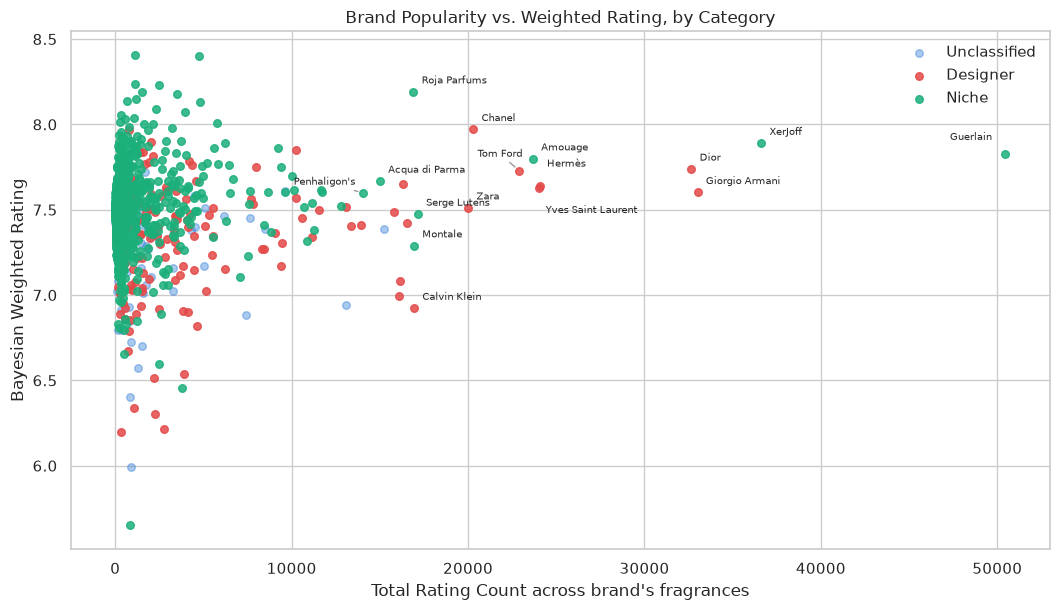

In [145]:
TOP_LABELS = 8  # label the top N by exposure within each category

top_designer = brand_level[brand_level["category"] == "Designer"].nlargest(TOP_LABELS, "total_count")
top_niche = brand_level[brand_level["category"] == "Niche"].nlargest(TOP_LABELS, "total_count")

# Only a few labels need a nudge: Tom Ford and Penhaligon's overlap their neighbors at the
# default offset (so they get a leader line back to their point), Guerlain's default offset
# pushes it past the right edge of the frame, and Hermès/Yves Saint Laurent sit almost on
# top of each other (their WR and total_count are only ~0.01 / ~70 apart).
LABEL_OFFSETS = {
    "Tom Ford": (-30, 10), "Penhaligon's": (-50, 6), "Guerlain": (-40, 10),
    "Hermès": (5, 14), "Yves Saint Laurent": (5, -18),
}
LEADER_LINES = {"Tom Ford", "Penhaligon's"}

COLORS = {"Designer": "#e34948", "Niche": "#1baf7a", "Unclassified": "#2a78d6"}

fig, ax = plt.subplots(figsize=(11, 6.5))
for cat in ["Unclassified", "Designer", "Niche"]:  # unclassified drawn first, underneath
    subset = brand_level[brand_level["category"] == cat]
    ax.scatter(subset["total_count"], subset["WR"], s=30,
               alpha=0.4 if cat == "Unclassified" else 0.85, color=COLORS[cat],
               zorder=1 if cat == "Unclassified" else 2, label=cat)

for name, row in pd.concat([top_designer, top_niche]).iterrows():
    ax.annotate(name, (row["total_count"], row["WR"]), textcoords="offset points",
                xytext=LABEL_OFFSETS.get(name, (6, 6)), fontsize=7.5,
                arrowprops=dict(arrowstyle="-", color="#999999", lw=1, shrinkA=0, shrinkB=4)
                if name in LEADER_LINES else None)

ax.set(xlabel="Total Rating Count across brand's fragrances", ylabel="Bayesian Weighted Rating",
       title="Brand Popularity vs. Weighted Rating, by Category")
ax.legend(frameon=False)
plt.show()

**The data**

`Brand_Category` is built from the full 1,451-brand list in `01_cleaning.ipynb`: **193 designer**, **1,152 niche** (default), **106 explicitly excluded**. Of those, 1,288 have at least one rated fragrance and so get a Bayesian Weighted Rating: **192 designer**, **997 niche**, **99 excluded** — essentially the full classification, since there's no `MIN_FRAGRANCES` cutoff left to shrink the pool. Averaging each brand's own WR (treating every brand equally regardless of size):

- **Designer** (192 brands): mean WR = 7.37
- **Niche** (997 brands): mean WR = 7.50
- **Unclassified** (99 brands): mean WR = 7.33

Same direction as with the old filtered approach (niche > designer), though the gap is a bit smaller now that thousands of small niche brands are pulled toward the population mean (7.50) rather than being excluded — many of them *are* the population mean now, by construction. The `total_count`-vs-WR correlation (r ≈ 0.13 designer, r ≈ 0.16 niche) is lower than the old `total_count`-vs-avg correlation (0.29 / 0.11) for the same reason: WR is partly *built* from total_count via the shrinkage formula, so a low-exposure brand's WR sits close to the population mean almost by construction, which mutes the correlation rather than purely reflecting a real popularity-quality relationship.

The highest-exposure names in each color are unchanged from before: **Roja Parfums** (niche, WR=8.19) and **Chanel** (designer, WR=7.97) remain the two standouts with real exposure behind them, followed by **XerJoff** (7.89), **Guerlain** (7.83), and **Amouage** (7.80) on the niche side, and **Dior** (7.74) and **Tom Ford** (7.73) on the designer side.

**The meaning**

Switching from hard cutoffs to shrinkage didn't flip the story — niche still edges out designer on average — but it changes *why* that finding can be trusted: it's no longer contingent on where `MIN_FRAGRANCES`/`MIN_RATING_COUNT` happened to be set. Every one of the 1,288 rated brands, from Guerlain's 50,000+ ratings down to a brand with a single 2-rating fragrance, is scored on the same formula, and the ones with too little data to say anything meaningful are honestly pulled toward "we don't know, assume average" instead of either being dropped or allowed to rank on noise. Niche houses with real exposure (Roja Parfums, Guerlain, XerJoff, Amouage) built that exposure by being well-regarded specialists; mass-market designer brands more often sell fragrance as a licensed extension of the fashion brand, which plausibly caps how high the average climbs even at scale (Calvin Klein, Zara). The designer/niche split still looks like it explains more about a brand's typical quality than raw popularity does on its own.

## Above and Beyond

My top pick: a lightweight content-based "find similar fragrances" recommender using the notes data — turn each fragrance's Top_Notes/Middle_Notes/Base_Notes into a set/vector and compute similarity (Jaccard or cosine on one-hot encoded notes) to recommend "if you like X, try Y." Most portfolio EDA projects stop at descriptive stats and bar charts; building even a simple similarity engine on messy multi-value text fields signals you can turn unstructured data into a feature representation and reason about a real product use case (recommendations, search relevance) — and you already have the explode_multi_value groundwork to build it on. Tradeoff: it's more build effort than a chart, but not much — a Jaccard similarity matrix on a few thousand fragrances is a straightforward pandas/numpy exercise, not a heavy ML lift.

Two cheaper but still compelling alternates if you want a narrative angle instead of a build:

**"Rise of Oud"** (or any note) over time — % of releases containing a given note by decade. Easy with tools you already have, and tells a real industry story (Middle Eastern influence entering mainstream Western perfumery) rather than just "here's a distribution."

**Popularity vs. quality tension** — does Rating_Count (exposure) correlate negatively with Rating_Value once you segment mass-market vs. niche brands? A "critical look at what the metric actually measures" angle, which reads as more mature than "top 10 brands by rating."

## 4. Example Explorations

Quick prototypes using the helper functions above — starting points, not full analyses.

In [146]:
value_counts_multi(df, "Perfumers").head(10)   # most prolific perfumers
value_counts_multi(df, "Main_Accords")          # frequency of every accord

Main_Accords
Floral          17699
Spicy           16719
Sweet           16341
Woody           15245
Fresh           14743
Fruity          11586
Citrus           8256
Green            7934
Powdery          7007
Synthetic        6287
Oriental         5871
Creamy           3916
Gourmand         3842
Resinous         3345
Aquatic          2700
Smoky            2683
Leathery         2351
Earthy           2008
Animal           1899
Chypre           1219
Fougère           566
Main Accords        1
Name: count, dtype: int64

In [147]:
# average rating per Top Note
notes = explode_multi_value(df, "Top_Notes")          # Series: index=original row, value=note
notes_df = notes.to_frame("Top_Note").join(df[["Rating_Value", "Brand"]])
notes_df.groupby("Top_Note")["Rating_Value"].mean().sort_values(ascending=False).head(10)

Top_Note
Sri Lankan oud          9.3
Anethol                 9.3
Cassia bark             9.3
Istanbul rose           9.3
Irish cream             9.1
Lemon mousse            9.1
Bolivian pink pepper    9.0
Poinsettia              9.0
Cep                     9.0
Bergamot CO2            9.0
Name: Rating_Value, dtype: float64

In [148]:
NOTE_COLUMNS = ["Top_Notes", "Middle_Notes", "Base_Notes"]

# Exact-token match: "Lemon" only matches the standalone note "Lemon"
lemon_exact = contains_value(df, NOTE_COLUMNS, "Lemon", exact=True)
print(f"Fragrances with 'Lemon' as an exact note: {lemon_exact.sum()}")

# Substring match: also catches variants like "Italian lemon", "lemon zest", "Amalfi lemon"
lemon_any = contains_value(df, NOTE_COLUMNS, "lemon", exact=False)
print(f"Fragrances with any note containing 'lemon': {lemon_any.sum()}")

# General analysis: most common Top Notes overall
value_counts_multi(df, "Top_Notes").head(10)

Fragrances with 'Lemon' as an exact note: 4787
Fragrances with any note containing 'lemon': 5857


Top_Notes
Bergamot           10785
Mandarin orange     5051
Lemon               4693
Grapefruit          2791
Pink pepper         2252
Orange              2236
Blackcurrant        1902
Cardamom            1865
Lavender            1650
Peach               1431
Name: count, dtype: int64